# SGAIM — Semana 1: O que é um sistema generativo?

**Hands-on: MNIST manifolds, distribuições e sampling**

8 secções (1–6 essenciais, 7–8 extensão)

Dependencies: `uv pip install numpy matplotlib scikit-learn umap-learn`

In [1]:
import random
import string
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Configuration
TSNE_SAMPLES = 7000
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [2]:
def load_mnist():
    """
    Load MNIST dataset. Uses fetch_openml (downloads on first run, caches after).
    Falls back to load_digits (8x8, 64D) if fetch_openml fails.
    """
    try:
        from sklearn.datasets import fetch_openml
        print("A carregar MNIST (784 dimensões, 70000 imagens)...")
        print("(Primeiro download ~50 MB — fica em cache para futuras utilizações)")
        mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="liac-arff")
        X = mnist.data.astype(np.float64)
        y = mnist.target.astype(int)
        img_shape = (28, 28)
        print(f"Carregado: {X.shape[0]} imagens, {X.shape[1]} dimensões.")
        return X, y, img_shape

    except Exception as e:
        print(f"Não foi possível carregar o MNIST: {e}")
        print("A usar fallback: sklearn.datasets.load_digits (8x8, 64 dimensões).")
        print("(Mesmos conceitos, menor escala — não precisa de internet.)")
        from sklearn.datasets import load_digits
        digits = load_digits()
        X = digits.data.astype(np.float64)
        y = digits.target.astype(int)
        img_shape = (8, 8)
        print(f"Carregado: {X.shape[0]} imagens, {X.shape[1]} dimensões.")
        return X, y, img_shape

X, y, img_shape = load_mnist()

A carregar MNIST (784 dimensões, 70000 imagens)...
(Primeiro download ~50 MB — fica em cache para futuras utilizações)
Carregado: 70000 imagens, 784 dimensões.


---
## Secção 1 — Carregar e explorar [Essencial]

Dimensões do dataset: (70000, 784)
Forma da imagem:      28x28 = 784 dimensões
Gama de pixels:       [0, 255]
Classes:              [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Amostras/classe:      ~7000

Cada pixel pode ter 256 valores.
Total de imagens possíveis: 256^784
Isso é aproximadamente 10^1887.
Para referência, átomos no universo ≈ 10^80.


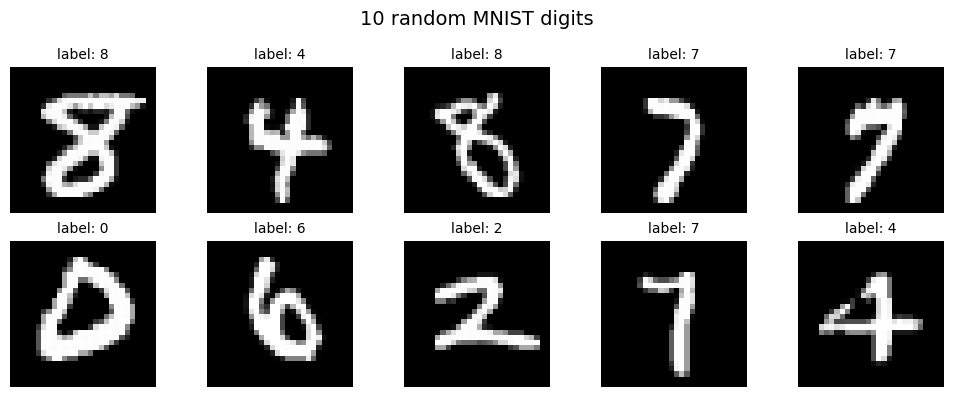

In [3]:
print(f"Dimensões do dataset: {X.shape}")
print(f"Forma da imagem:      {img_shape[0]}x{img_shape[1]} = {img_shape[0] * img_shape[1]} dimensões")
print(f"Gama de pixels:       [{X.min():.0f}, {X.max():.0f}]")
print(f"Classes:              {sorted(int(c) for c in np.unique(y))}")
print(f"Amostras/classe:      ~{len(y) // 10}")

# Show 10 random digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("10 random MNIST digits", fontsize=14)
indices = np.random.choice(len(X), 10, replace=False)
for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X[idx].reshape(img_shape), cmap="gray")
    ax.set_title(f"label: {y[idx]}", fontsize=10)
    ax.axis("off")
plt.tight_layout()

n_dims = img_shape[0] * img_shape[1]
pixel_max = 256 if n_dims == 784 else 16
print(f"\nCada pixel pode ter {pixel_max} valores.")
print(f"Total de imagens possíveis: {pixel_max}^{n_dims}")
if n_dims == 784:
    print("Isso é aproximadamente 10^1887.")
    print("Para referência, átomos no universo ≈ 10^80.")

> **PREDICT:** Quantas dessas 10^1887 imagens se parecem com dígitos reais?

> **Desafio:** Mostra 10 imagens do dígito 7 em vez de aleatórias. Quantas variações vês?
> Cria uma cell nova abaixo e experimenta.

In [3]:
len(X)

70000

Dimensões do dataset: (70000, 784)
Forma da imagem:      28x28 = 784 dimensões
Gama de pixels:       [0, 255]
Classes:              [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Amostras/classe:      ~7000

Cada pixel pode ter 256 valores.
Total de imagens possíveis: 256^784
Isso é aproximadamente 10^1887.
Para referência, átomos no universo ≈ 10^80.


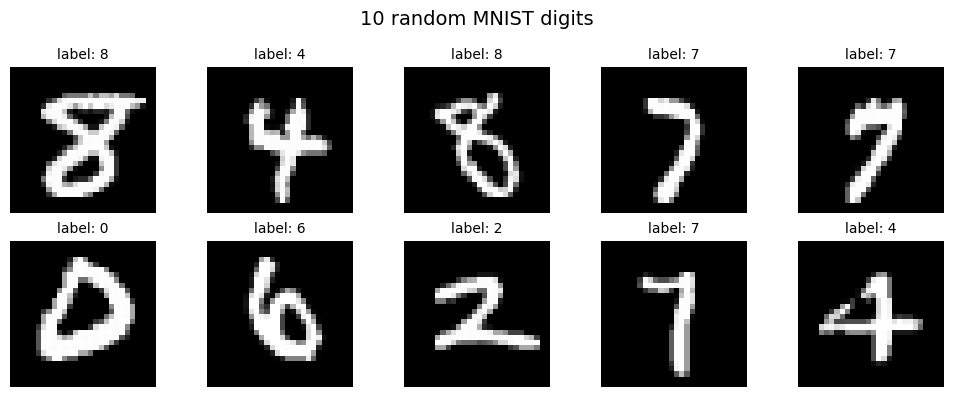

In [4]:
print(f"Dimensões do dataset: {X.shape}")
print(f"Forma da imagem:      {img_shape[0]}x{img_shape[1]} = {img_shape[0] * img_shape[1]} dimensões")
print(f"Gama de pixels:       [{X.min():.0f}, {X.max():.0f}]")
print(f"Classes:              {sorted(int(c) for c in np.unique(y))}")
print(f"Amostras/classe:      ~{len(y) // 10}")

# Show 10 random digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("10 random MNIST digits", fontsize=14)
indices = np.random.choice(len(X), 10, replace=False)
for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X[idx].reshape(img_shape), cmap="gray")
    ax.set_title(f"label: {y[idx]}", fontsize=10)
    ax.axis("off")
plt.tight_layout()

n_dims = img_shape[0] * img_shape[1]
pixel_max = 256 if n_dims == 784 else 16
print(f"\nCada pixel pode ter {pixel_max} valores.")
print(f"Total de imagens possíveis: {pixel_max}^{n_dims}")
if n_dims == 784:
    print("Isso é aproximadamente 10^1887.")
    print("Para referência, átomos no universo ≈ 10^80.")

---
## Secção 2 — Aleatório vs real [Essencial]

> **PREDICT:** Se escolheres pixels aleatórios, o que vais ver — ruído estático, uma forma desfocada, ou algo reconhecível?

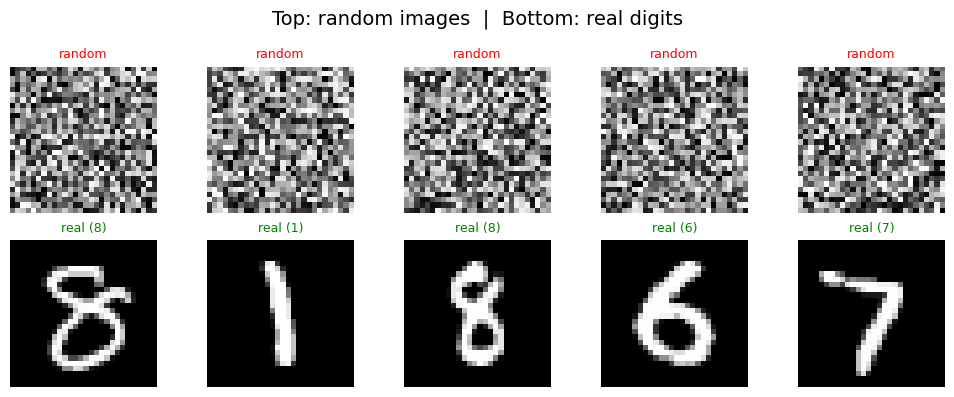

In [5]:
n_dims = img_shape[0] * img_shape[1]
pixel_max_val = 255.0 if n_dims == 784 else 16.0

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Top: random images  |  Bottom: real digits", fontsize=14)

# Top row: random
for ax in axes[0]:
    random_img = np.random.uniform(0, pixel_max_val, size=n_dims)
    ax.imshow(random_img.reshape(img_shape), cmap="gray")
    ax.set_title("random", fontsize=9, color="red")
    ax.axis("off")

# Bottom row: real
indices = np.random.choice(len(X), 5, replace=False)
for ax, idx in zip(axes[1], indices):
    ax.imshow(X[idx].reshape(img_shape), cmap="gray")
    ax.set_title(f"real ({y[idx]})", fontsize=9, color="green")
    ax.axis("off")

plt.tight_layout()

Pixels aleatórios = ruído. Dígitos reais têm estrutura.

As imagens reais ocupam uma fracção **minúscula** do espaço total. Isto é a **manifold hypothesis** em acção.

> **Desafio:** Gera imagens com Gaussiana (média=128, sigma=50) em vez de uniforme. Parecem mais com dígitos?

---
## Secção 3 — Médias por classe [Essencial]

> **PREDICT:** Como será a imagem média de todos os '3's? Nítida ou desfocada?

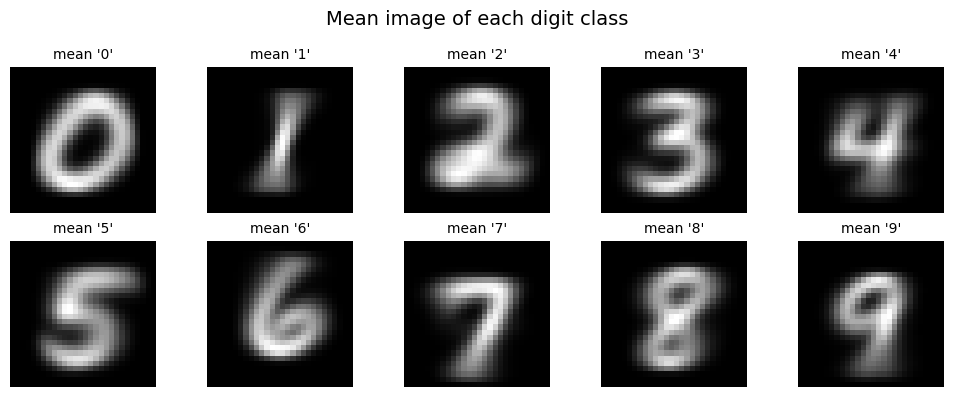

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Mean image of each digit class", fontsize=14)

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    mask = y == digit
    mean_img = X[mask].mean(axis=0)
    ax.imshow(mean_img.reshape(img_shape), cmap="gray")
    ax.set_title(f"mean '{digit}'", fontsize=10)
    ax.axis("off")

plt.tight_layout()

Cada média é reconhecível — mas **desfocada**.

A média captura a forma típica, mas perde a variação. É uma estatística descritiva, **não** um dígito real. Ninguém escreve o '3 médio' — é uma abstracção.

> **Desafio:** Calcula a média de TODOS os dígitos juntos. O que obtens? Porquê?

---
## Secção 4 — t-SNE + UMAP: visualizar o manifold [Essencial]

> **PREDICT:** Quando projectamos dígitos de 784 dimensões para 2D, vamos ver dispersão aleatória — ou estrutura?

**NOTA IMPORTANTE:** O t-SNE é **não-supervisionado** — não recebe os labels (0–9). As cores são adicionadas **depois**, para confirmar o que o algoritmo descobriu sozinho.

A correr t-SNE em 7000 amostras... (pode demorar 1–2 minutos)
t-SNE concluído.
A correr UMAP nos mesmos 7000 dados...


/Users/btavr/dev/isel/2oSem/sgaim/sgaim/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP concluído.


Text(0, 0.5, 'UMAP 2')

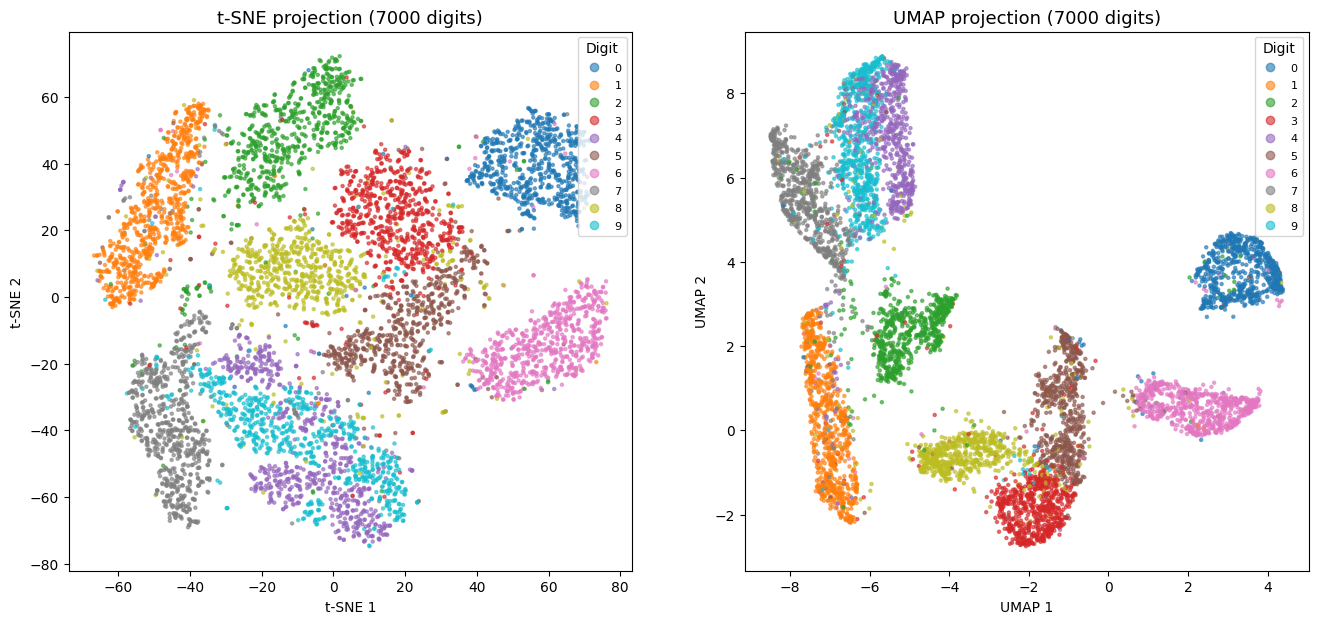

In [7]:
from sklearn.manifold import TSNE
import umap

n = min(TSNE_SAMPLES, len(X))
indices = np.random.choice(len(X), n, replace=False)
X_sub = X[indices]
y_sub = y[indices]

# t-SNE
print(f"A correr t-SNE em {n} amostras... (pode demorar 1–2 minutos)")
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X_sub)
print("t-SNE concluído.")

# UMAP
print(f"A correr UMAP nos mesmos {n} dados...")
reducer = umap.UMAP(n_components=2, random_state=RANDOM_SEED)
X_umap = reducer.fit_transform(X_sub)
print("UMAP concluído.")

# Side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

scatter1 = ax1.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=y_sub, cmap="tab10", s=5, alpha=0.6
)
ax1.legend(
    *scatter1.legend_elements(),
    title="Digit", loc="upper right", fontsize=8
)
ax1.set_title(f"t-SNE projection ({n} digits)", fontsize=13)
ax1.set_xlabel("t-SNE 1")
ax1.set_ylabel("t-SNE 2")

scatter2 = ax2.scatter(
    X_umap[:, 0], X_umap[:, 1],
    c=y_sub, cmap="tab10", s=5, alpha=0.6
)
ax2.legend(
    *scatter2.legend_elements(),
    title="Digit", loc="upper right", fontsize=8
)
ax2.set_title(f"UMAP projection ({n} digits)", fontsize=13)
ax2.set_xlabel("UMAP 1")
ax2.set_ylabel("UMAP 2")

**Estrutura!** Dígitos da mesma classe agrupam-se. Dígitos semelhantes (3/8, 4/9, 7/1) ficam próximos.

Alguns dígitos partilham zona — são visualmente semelhantes. O manifold de 4s e 9s está próximo em 784D.

**IMPORTANTE sobre o t-SNE:**
- Preserva vizinhanças **locais**, não distâncias globais
- A distância entre clusters **não** é significativa
- O tamanho dos clusters **não** é significativo
- Mas a **existência** de clusters é significativa — revela o manifold

**UMAP** preserva mais estrutura **global**: clusters mais compactos, relações entre classes mais visíveis. É também ~10x mais rápido.

> **Desafio:** Muda o perplexity do t-SNE para 5 e depois para 100. O que acontece?

---
## Secção 5 — Gaussian Sampling — o clímax [Essencial]

In [8]:
target_digit = 3
mask = y == target_digit
X_class = X[mask]

print(f"Temos {X_class.shape[0]} imagens do dígito '{target_digit}'.")
print(f"Cada imagem é um ponto no espaço {X_class.shape[1]}-dimensional.")
print()
print("Plano:")
print(f"  1. Calcular a média de todos os '{target_digit}'s")
print(f"  2. Calcular a matriz de covariância ({X_class.shape[1]}x{X_class.shape[1]})")
print(f"  3. Ajustar uma Gaussiana multivariada: N(μ, Σ)")
print(f"  4. Fazer sampling de 10 novos pontos dessa Gaussiana")
print(f"  5. Reshape cada sample para uma imagem {img_shape[0]}x{img_shape[1]}")

Temos 7141 imagens do dígito '3'.
Cada imagem é um ponto no espaço 784-dimensional.

Plano:
  1. Calcular a média de todos os '3's
  2. Calcular a matriz de covariância (784x784)
  3. Ajustar uma Gaussiana multivariada: N(μ, Σ)
  4. Fazer sampling de 10 novos pontos dessa Gaussiana
  5. Reshape cada sample para uma imagem 28x28


> **PREDICT:** Os samples Gaussianos vão parecer 3s manuscritos reais? Porquê ou porque não?

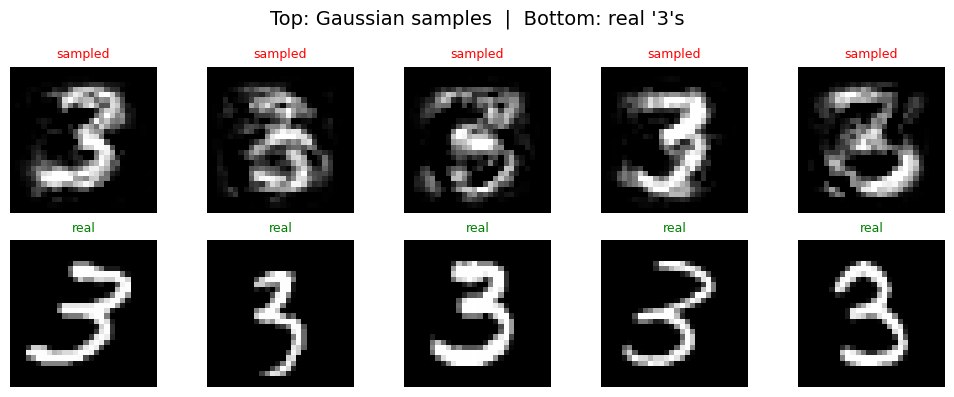

In [9]:
# Compute mean and regularised covariance
mean = X_class.mean(axis=0)
cov = np.cov(X_class, rowvar=False)
cov += 1e-4 * np.eye(cov.shape[0])  # regularisation to avoid singularity

# Sample
samples = np.random.multivariate_normal(mean, cov, size=10)

# Clip to valid pixel range
pixel_max_clip = 255.0 if img_shape == (28, 28) else 16.0
samples = np.clip(samples, 0, pixel_max_clip)

# Display: top row = Gaussian samples, bottom row = real digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle(
    f"Top: Gaussian samples  |  Bottom: real '{target_digit}'s",
    fontsize=14
)

for i, ax in enumerate(axes[0]):
    ax.imshow(samples[i].reshape(img_shape), cmap="gray")
    ax.set_title("sampled", fontsize=9, color="red")
    ax.axis("off")

real_indices = np.random.choice(X_class.shape[0], 5, replace=False)
for ax, idx in zip(axes[1], real_indices):
    ax.imshow(X_class[idx].reshape(img_shape), cmap="gray")
    ax.set_title("real", fontsize=9, color="green")
    ax.axis("off")

plt.tight_layout()

Os samples Gaussianos são desfocados e ruidosos — claramente não são dígitos reais.

**Porquê?** Uma Gaussiana é um blob elipsoidal em 784D. Mas o manifold de 3s reais **não** é um blob — tem curvas, ramificações, regiões finas. A Gaussiana espalha massa de probabilidade no vasto espaço vazio onde nenhum dígito real existe.

O modelo é matematicamente correcto — mas demasiado simples. Não consegue capturar a **geometria** do manifold. É por isto que precisamos de deep generative models.

In [9]:
# Quantitative comparison: how far are the samples from real data?
from sklearn.metrics import pairwise_distances

n_compare = min(100, len(samples), X_class.shape[0])
dists_fake_to_real = pairwise_distances(
    samples[:n_compare], X_class[:500]
).min(axis=1)

real_subset = X_class[np.random.choice(X_class.shape[0], n_compare, replace=False)]
dists_real_to_real = pairwise_distances(
    real_subset, X_class[:500]
)
np.fill_diagonal(dists_real_to_real[:n_compare, :n_compare], np.inf)
dists_real_to_real = dists_real_to_real.min(axis=1)

print(f"Sample Gaussiano → dígito real mais próximo: {dists_fake_to_real.mean():.0f} (distância média em pixels)")
print(f"Dígito real → vizinho real mais próximo:     {dists_real_to_real.mean():.0f} (distância média em pixels)")
print(f"Ratio: {dists_fake_to_real.mean() / dists_real_to_real.mean():.1f}x mais longe")
print()
print("Os samples Gaussianos vivem LONGE do manifold dos dados reais.")

Sample Gaussiano → dígito real mais próximo: 1460 (distância média em pixels)
Dígito real → vizinho real mais próximo:     1320 (distância média em pixels)
Ratio: 1.1x mais longe

Os samples Gaussianos vivem LONGE do manifold dos dados reais.


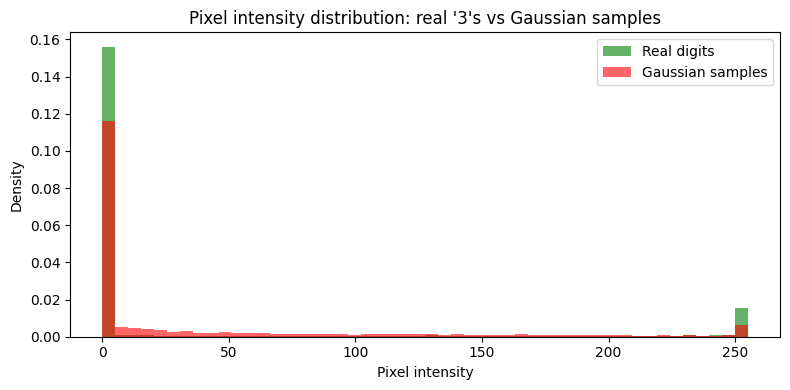

In [10]:
# Intensity histogram: Gaussian samples vs real digits
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    X_class.ravel(), bins=50, alpha=0.6, density=True,
    label="Real digits", color="green"
)
ax.hist(
    samples.ravel(), bins=50, alpha=0.6, density=True,
    label="Gaussian samples", color="red"
)
ax.set_xlabel("Pixel intensity")
ax.set_ylabel("Density")
ax.set_title(f"Pixel intensity distribution: real '{target_digit}'s vs Gaussian samples")
ax.legend()
plt.tight_layout()

Dígitos reais têm distribuição **bimodal**: maioritariamente 0 (fundo) e concentrações perto de valores altos (tinta). Os samples Gaussianos espalham probabilidade pela zona intermédia — o 'espaço vazio' onde nenhum pixel real vive.

### Conclusões-chave

1. Os dados reais vivem num **manifold minúsculo** num espaço vasto
2. Uma Gaussiana **não consegue** capturar a geometria do manifold
3. Precisamos de modelos que aprendam a **forma** do manifold

→ Próxima semana: o **Transformer**

> **Desafio:** Muda `target_digit` para 1. Os samples ficam melhores ou piores? (Dica: geometria do 1)

---
## Secção 6 — Do pixel ao token: o manifold do texto [Essencial]

Até agora trabalhámos com imagens. Mas a mesma ideia aplica-se a **texto**.

In [11]:
# 6a: Random tokens vs real text
charset = string.ascii_lowercase + " "
random_text = "".join(random.choice(charset) for _ in range(80))

real_text = "os dados reais vivem numa superfície fina embebida num espaço imenso"

print("Sequência aleatória de caracteres (distribuição uniforme):")
print(f'  "{random_text}"')
print()
print("Frase real em português:")
print(f'  "{real_text}"')

Sequência aleatória de caracteres (distribuição uniforme):
  "udaxihhexdvxrcsnbacghqtargwuwrnhosizayzfwnkiegykdcmdlltizbxordmcrj utlsgwcbvhyjc"

Frase real em português:
  "os dados reais vivem numa superfície fina embebida num espaço imenso"


O paralelo é exacto: o espaço de todas as sequências de caracteres é imenso, mas as frases com significado ocupam uma fracção minúscula.

**Imagens** → manifold de dígitos. **Texto** → manifold de frases com sentido.

Em português real, ' ', 'e', 'a' dominam.
Caracteres como 'w', 'x', 'k' são raríssimos.
Mesmo a frequência individual já mostra estrutura — mas não chega.


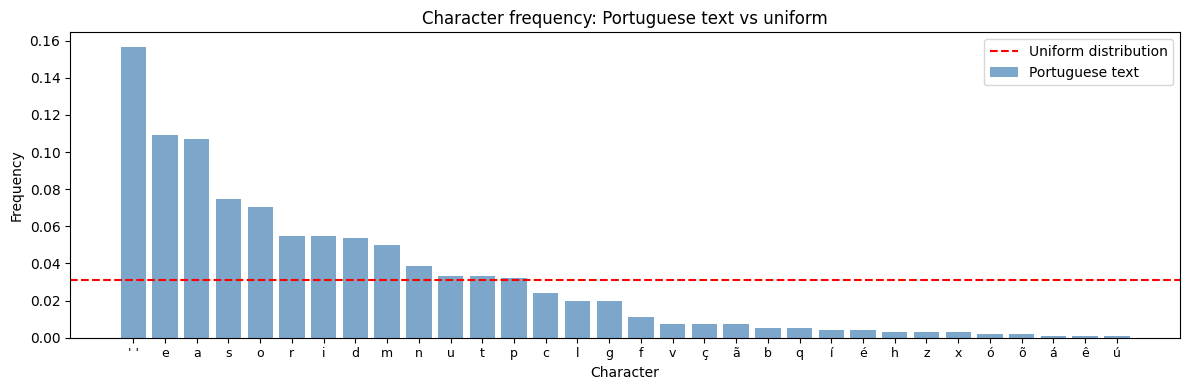

In [12]:
# 6b: Character frequency — uniform vs Portuguese
_TEXTO_PT = (
    "Os dados reais vivem numa superfície fina embebida num espaço de alta dimensão. "
    "Esta é a hipótese do manifold. Cada imagem de um dígito manuscrito não é um ponto "
    "aleatório no espaço de todas as imagens possíveis. Pelo contrário pertence a uma "
    "região restrita onde as imagens fazem sentido. Um modelo generativo tem de aprender "
    "a forma dessa região para conseguir gerar novos exemplos realistas. Uma gaussiana "
    "simples não consegue capturar essa geometria porque espalha probabilidade em todas "
    "as direcções igualmente. Precisamos de modelos mais poderosos que aprendam a "
    "estrutura curva e ramificada do manifold dos dados reais. A linguagem humana tem "
    "exactamente a mesma propriedade. O espaço de todas as sequências de caracteres é "
    "imenso mas as frases com significado ocupam uma fracção minúscula desse espaço. "
    "Aprender a distribuição do texto é aprender a geometria desse manifold linguístico. "
    "Cada palavra que dizemos segue padrões que um modelo pode aprender a reproduzir."
)

texto = _TEXTO_PT.lower()

freq = Counter(c for c in texto if c.isalpha() or c == " ")
chars_sorted = sorted(freq.keys(), key=lambda c: freq[c], reverse=True)
counts = [freq[c] for c in chars_sorted]
total_chars = sum(counts)
freqs_real = [c / total_chars for c in counts]
uniform_freq = 1.0 / len(chars_sorted)

fig, ax = plt.subplots(figsize=(12, 4))
x_pos = range(len(chars_sorted))
labels = ["' '" if c == " " else c for c in chars_sorted]
ax.bar(x_pos, freqs_real, alpha=0.7, label="Portuguese text", color="steelblue")
ax.axhline(y=uniform_freq, color="red", linestyle="--", label="Uniform distribution")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(labels, fontsize=9)
ax.set_xlabel("Character")
ax.set_ylabel("Frequency")
ax.set_title("Character frequency: Portuguese text vs uniform")
ax.legend()
plt.tight_layout()

top3 = ", ".join(f"'{c}'" for c in chars_sorted[:3])
print(f"Em português real, {top3} dominam.")
print("Caracteres como 'w', 'x', 'k' são raríssimos.")
print("Mesmo a frequência individual já mostra estrutura — mas não chega.")

> **PREDICT:** Se gerarmos texto caracter a caracter, condicionando no anterior (modelo bigram) — o resultado parecerá português, inglês, ou ruído?

In [13]:
# 6c: Bigram model — the autoregressive idea
bigrams = {}
for i in range(len(texto) - 1):
    c1, c2 = texto[i], texto[i + 1]
    bigrams.setdefault(c1, []).append(c2)

# Generate text from bigram model
seed = "a"
result = [seed]
for _ in range(120):
    c = result[-1]
    if c in bigrams:
        result.append(random.choice(bigrams[c]))
    else:
        result.append(random.choice(list(bigrams.keys())))
bigram_text = "".join(result)

print(f"Texto gerado pelo modelo bigram:")
print(f'  "{bigram_text}"')

Texto gerado pelo modelo bigram:
  "a é ges rquenspreniçonsm sinão pa ptráraplifreseitrada ntosimado ass detode va nifo a de diçõe pasaspr abifis eres ns uma"


Repara: começa a parecer português! Sílabas reconhecíveis, espaços nos sítios aproximadamente certos.

Cada passo de **condicionamento** melhora o resultado:
- **0 contexto** (uniforme): ruído total
- **1 caracter** anterior (bigram): sílabas reconhecíveis
- **2–3 caracteres**: palavras curtas plausíveis
- **TODOS os anteriores**: modelação autoregressiva → **Transformer**

**p(x) = p(x₁) · p(x₂|x₁) · p(x₃|x₁,x₂) · ...** — é ISTO que o GPT faz.

### A ligação de volta ao MNIST

| Imagens | Texto |
|---------|-------|
| Pixels | Tokens (caracteres ou subpalavras) |
| Imagens | Frases |
| Manifold de dígitos | Manifold de texto com significado |

A decomposição autoregressiva:

**p(x) = p(x₁) · p(x₂|x₁) · p(x₃|x₁,x₂) · ...**

funciona para **ambos**. É a ideia central do Transformer.

---

As secções essenciais estão completas.

As secções 7–8 são de **extensão** — para alunos rápidos ou para rever em casa.

---
## Secção 7 — Interpolação [Extensão]

> **PREDICT:** Se interpolarmos entre a média do '3' e a média do '8', as imagens intermédias vão parecer dígitos reais?

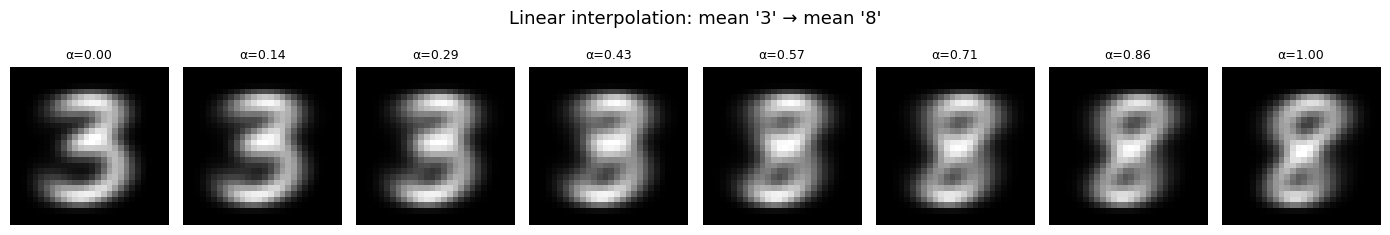

In [14]:
digit_a, digit_b = 3, 8
mean_a = X[y == digit_a].mean(axis=0)
mean_b = X[y == digit_b].mean(axis=0)

n_steps = 8
alphas = np.linspace(0, 1, n_steps)

fig, axes = plt.subplots(1, n_steps, figsize=(14, 2.5))
fig.suptitle(
    f"Linear interpolation: mean '{digit_a}' → mean '{digit_b}'",
    fontsize=13
)

for ax, alpha in zip(axes, alphas):
    interp = (1 - alpha) * mean_a + alpha * mean_b
    ax.imshow(interp.reshape(img_shape), cmap="gray")
    ax.set_title(f"α={alpha:.2f}", fontsize=9)
    ax.axis("off")

plt.tight_layout()

As imagens intermédias são fantasmagóricas — não parecem nenhum dígito real.

Isto diz-nos algo importante: a **linha recta** entre a média do '3' e a média do '8' no espaço de pixels **não** segue o manifold.

Bons modelos generativos (VAEs, diffusion) aprendem um **espaço latente** onde linhas rectas **sim** seguem o manifold — produzindo imagens realistas em cada passo. É a diferença entre interpolar no espaço de pixels e interpolar numa representação aprendida.

---
## Secção 8 — Discussão [Extensão]

Pensem nisto para a próxima semana:

1. Ajustámos uma Gaussiana ao dígito '3' e falhou. Ajustar uma **mistura de Gaussianas** ajudaria? Porquê? Quantas seriam precisas?

2. O t-SNE mostrou-nos clusters em 2D. Mas os dígitos reais da mesma classe têm enorme variação (grossos/finos, inclinados/direitos, grandes/pequenos). Como pode o manifold ser 'de baixa dimensão' se há tanta variação?

3. O GPT gera texto um **token** de cada vez, condicionando em todos os tokens anteriores: p(x₁)·p(x₂|x₁)·p(x₃|x₁,x₂)·... Como é que esta estratégia evita o problema que a Gaussiana teve?

4. Usámos 70.000 imagens de treino. LLMs modernos treinam com triliões de tokens. A abordagem Gaussiana funcionaria melhor com mais dados — ou o problema é fundamental?

Estas perguntas ligam-se directamente ao que vamos estudar: a arquitectura Transformer e a geração autoregressiva.

---

**Próxima semana:** arquitectura Transformer.